## Project Setup, Utilities, and Data Preparation

This cell sets up the project environment, defines utility functions for path resolution, checkpoint management, and result resetting. It loads the master dataset, prepares language code mappings, and builds a dictionary of available dataset files for further processing.

In [ ]:
# ============================================================
# RESTART UTILITIES - Iteration 2
# ============================================================

import os
import json
import glob
import shutil
from pathlib import Path
from typing import Union, Optional
import pandas as pd

# Cross-platform path resolution (consistent with Iteration 0 & 1)
def find_project_root_with_datasets(start_path: Path, max_levels: int = 10) -> Path:
    """
    Search upward from start_path for a directory containing 'Datasets' folder.
    This makes the notebook work on any system (macOS, Windows, Linux).
    """
    cur = start_path.resolve()
    for _ in range(max_levels):
        if (cur / 'Datasets').exists():
            return cur
        cur = cur.parent
    raise FileNotFoundError(
        f"Could not find project root with 'Datasets' folder within {max_levels} levels. "
        f"Set THESIS_BASE_DIR environment variable or ensure Datasets folder exists."
    )

# Try environment variable first, then search for project root
env_base = os.environ.get('THESIS_BASE_DIR')
if env_base:
    BASE_DIR = Path(env_base)
else:
    BASE_DIR = find_project_root_with_datasets(Path.cwd())

PATHS = {
    'master_dataset':   BASE_DIR / "Master Dataset 34k",
    'embeddings':       BASE_DIR / "Embeddings" / "_iteration_2",
    'results':          BASE_DIR / "Results" / "_iteration_2"
}

# Normalize all paths
for k, p in list(PATHS.items()):
    PATHS[k] = Path(p).resolve()
    PATHS[k].mkdir(parents=True, exist_ok=True)

DATA_DIR            = str(PATHS['master_dataset'])
EMBEDDINGS_BASE_DIR = str(PATHS['embeddings'])
RESULTS_DIR         = str(PATHS['results'])
CHECKPOINT_FILE     = str(PATHS['results'] / "checkpoint_iteration_2.json")

# =============================================================================
# Language code mapping (consistent with Iteration 0)
# =============================================================================
LANGUAGE_CODE_MAP = {
    'English': 'EN', 'German': 'DE', 'Swedish': 'SV',
    'Dutch':   'NL'
}

# =============================================================================
# Load Master Dataset (pre-processed in Iteration 0)
# =============================================================================
master_df = pd.read_json(PATHS['master_dataset'] / 'master_df.json')
print(f"Loaded master_df: {len(master_df):,} records, {master_df.shape[1]} columns")


DATASET_FILES = {
    'english_manual':     str(PATHS['master_dataset'] / 'By_SL_Country' / 'master_df_English_manual.json'),
    'german_manual':      str(PATHS['master_dataset'] / 'By_SL_Country' / 'master_df_Germany_manual.json'),
    'swedish_manual':     str(PATHS['master_dataset'] / 'By_SL_Country' / 'master_df_Sweden_manual.json'),
    'dutch_manual':       str(PATHS['master_dataset'] / 'By_SL_Country' / 'master_df_Netherlands_manual.json'),
}
# Only include files that exist
DATASET_FILES = {k: v for k, v in DATASET_FILES.items() if os.path.exists(v)}
print(f"Dataset files available: {list(DATASET_FILES.keys())}")


def reset_checkpoint():
    """Delete checkpoint to restart from beginning"""
    if os.path.exists(CHECKPOINT_FILE):
        os.remove(CHECKPOINT_FILE)
        print(" Checkpoint cleared - will restart from beginning")
    else:
        print(" No checkpoint found - already clean")

def view_progress():
    """View current progress"""
    if os.path.exists(CHECKPOINT_FILE):
        with open(CHECKPOINT_FILE, 'r') as f:
            data = json.load(f)
            processed = data['processed']
            print(f"Processed combinations: {len(processed)}")
            print("\nCompleted:")
            for item in processed:
                # Handle both tuple formats: (model, dataset) or single values
                if isinstance(item, (list, tuple)) and len(item) >= 2:
                    model, dataset = item[0], item[1]
                    print(f"  - {model:20s} → {dataset}")
                else:
                    print(f"  - {item}")
    else:
        print("No checkpoint found - no progress yet")

def reset_embeddings():
    """Delete all generated embeddings"""
    if os.path.exists(EMBEDDINGS_BASE_DIR):
        response = input(f"  Delete ALL embeddings in {EMBEDDINGS_BASE_DIR}? (yes/no): ")
        if response.lower() == 'yes':
            shutil.rmtree(EMBEDDINGS_BASE_DIR)
            os.makedirs(EMBEDDINGS_BASE_DIR)
            print("All embeddings deleted")
        else:
            print(" Cancelled")
    else:
        print("Embeddings directory doesn't exist")

def reset_results():
    """Delete all results"""
    if os.path.exists(RESULTS_DIR):
        response = input(f"  Delete ALL results in {RESULTS_DIR}? (yes/no): ")
        if response.lower() == 'yes':
            for file in glob.glob(os.path.join(RESULTS_DIR, '*')):
                os.remove(file)
            print("All results deleted")
        else:
            print("Cancelled")
    else:
        print(" Results directory doesn't exist")

def full_reset():
    """Complete reset - checkpoint, embeddings, and results"""
    print("="*60)
    print(" FULL RESET WARNING")
    print("="*60)
    response = input("This will delete EVERYTHING (checkpoint, embeddings, results). Continue? (yes/no): ")
    if response.lower() == 'yes':
        reset_checkpoint()
        if os.path.exists(EMBEDDINGS_BASE_DIR):
            shutil.rmtree(EMBEDDINGS_BASE_DIR)
            os.makedirs(EMBEDDINGS_BASE_DIR)
            print(" Embeddings deleted")
        if os.path.exists(RESULTS_DIR):
            for file in glob.glob(os.path.join(RESULTS_DIR, '*')):
                os.remove(file)
            print(" Results deleted")
        print("\n Full reset complete - Ready for fresh start")
    else:
        print(" Cancelled")

def remove_specific_model(model_key):
    """Remove specific model from checkpoint to reprocess it"""
    if os.path.exists(CHECKPOINT_FILE):
        with open(CHECKPOINT_FILE, 'r') as f:
            data = json.load(f)
            processed = data['processed']
        
        # Filter out the specific model
        original_count = len(processed)
        processed = [item for item in processed if item[0] != model_key]
        removed_count = original_count - len(processed)
        
        # Save updated checkpoint
        with open(CHECKPOINT_FILE, 'w') as f:
            json.dump({'processed': processed}, f)
        
        print(f" Removed {removed_count} combinations for model: {model_key}")
        print(f"Remaining: {len(processed)} combinations")
    else:
        print("No checkpoint found")


def remove_specific_dataset(dataset_name):
    """Remove specific dataset from checkpoint to reprocess it"""
    if os.path.exists(CHECKPOINT_FILE):
        with open(CHECKPOINT_FILE, 'r') as f:
            data = json.load(f)
            processed = data['processed']
        
        # Filter out the specific dataset
        original_count = len(processed)
        processed = [item for item in processed if item[1] != dataset_name]
        removed_count = original_count - len(processed)
        
        # Save updated checkpoint
        with open(CHECKPOINT_FILE, 'w') as f:
            json.dump({'processed': processed}, f)
        
        print(f" Removed {removed_count} combinations for dataset: {dataset_name}")
        print(f"Remaining: {len(processed)} combinations")
    else:
        print("No checkpoint found")

def complete_rerun():
    """Simple one-command complete restart"""
    print("\n" + "="*60)
    print(" COMPLETE RERUN")
    print("="*60)
    print("This will:")
    print("  1. Clear checkpoint file")
    print("  2. Delete all embeddings")
    print("  3. Delete all results")
    print("  4. Start fresh from beginning")
    print("="*60)
    response = input("\nProceed with complete rerun? (yes/no): ")
    if response.lower() == 'yes':
        # Clear checkpoint
        if os.path.exists(CHECKPOINT_FILE):
            os.remove(CHECKPOINT_FILE)
            print("Checkpoint cleared")
        
        # Clear embeddings
        if os.path.exists(EMBEDDINGS_BASE_DIR):
            shutil.rmtree(EMBEDDINGS_BASE_DIR)
            os.makedirs(EMBEDDINGS_BASE_DIR)
            print(" Embeddings deleted")
        
        # Clear results
        if os.path.exists(RESULTS_DIR):
            for file in glob.glob(os.path.join(RESULTS_DIR, '*')):
                os.remove(file)
            print(" Results deleted")
        
        print("\n" + "="*60)
        print(" COMPLETE RERUN READY")
        print("="*60)
        print("Now run the main pipeline cell to start fresh!")
        print("="*60)
    else:
        print(" Cancelled")

# ============================================================
# Quick Commands - Uncomment the one you want to run
# ============================================================

# View current progress
view_progress()

# To reset just checkpoint (keeps embeddings/results):
# reset_checkpoint()

# To remove a specific model (e.g., to reprocess it):
# remove_specific_model('modernbert-large')

# To remove a specific dataset (e.g., to reprocess it):
# remove_specific_dataset('sweden')

# To do a complete rerun:
# complete_rerun()

print("\n" + "="*60)
print("RESTART UTILITIES LOADED")
print("="*60)
print("Available functions:")
print("  view_progress()              - See what's completed")
print("  reset_checkpoint()           - Clear checkpoint only")
print("  remove_specific_model(name)  - Remove model from checkpoint")
print("  remove_specific_dataset(name)- Remove dataset from checkpoint")
print("  reset_embeddings()           - Delete all embeddings")
print("  reset_results()              - Delete all results")
print("  complete_rerun()             - COMPLETE RESTART (everything)")
print("="*60)
print("\nTIP: To completely restart everything, run: complete_rerun()")

Loaded master_df: 34,576 records, 36 columns
Dataset files available: ['english_manual', 'german_manual', 'swedish_manual', 'dutch_manual']
No checkpoint found - no progress yet

RESTART UTILITIES LOADED
Available functions:
  view_progress()              - See what's completed
  reset_checkpoint()           - Clear checkpoint only
  remove_specific_model(name)  - Remove model from checkpoint
  remove_specific_dataset(name)- Remove dataset from checkpoint
  reset_embeddings()           - Delete all embeddings
  reset_results()              - Delete all results
  complete_rerun()             - COMPLETE RESTART (everything)

TIP: To completely restart everything, run: complete_rerun()


## (Optional) Complete Rerun Command

This cell provides a command to trigger a complete rerun of the pipeline, clearing all checkpoints, embeddings, and results if uncommented and executed.

In [33]:
# complete_rerun()

## Main Pipeline: Model Training, Embedding Generation, and Evaluation

This cell contains the main execution logic for the pipeline. It configures paths and model settings, defines functions for generating BERT embeddings, processing datasets, and training SVM classifiers. The cell iterates over all model-dataset combinations, generates embeddings, trains classifiers, evaluates results, and prints detailed performance metrics and summary statistics. It also saves results and manages checkpoints for resumable execution.


################################################################################
MULTI-MODEL EMBEDDING AND SVM TRAINING PIPELINE
################################################################################

Datasets to process: 4
  english_manual: master_df_English_manual.json
  german_manual: master_df_Germany_manual.json
  swedish_manual: master_df_Sweden_manual.json
  dutch_manual: master_df_Netherlands_manual.json

Found 6 models to use
Total combinations: 24
Already processed: 0 combinations

################################################################################
MODEL: bert-base-cased (bert-base-cased)
################################################################################

Initializing bert-base-cased...


/Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/.venv/lib/python3.9/site-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Model loaded successfully!

PHASE 1: GENERATING EMBEDDINGS - bert-base-cased

Processing: english_manual | Model: bert-base-cased
Dataset shape: (4713, 36)

Case type distribution:
CASE_TYPE
Safety                              2553
Process Safety                      1409
Environment                          454
Asset and Reputation damage/loss     145
Operational loss                     123
Physical Security                     14
Information Security                  12
Not classified                         3
Name: count, dtype: int64

Generating bert-base-cased embeddings...
Using device: cpu


Generating embeddings: 100%|██████████| 1179/1179 [02:11<00:00,  8.98it/s]



Training set: (3770, 768)
Test set: (943, 768)

Class distribution in training set:
binary_label
0    70.11%
1    29.89%
Name: proportion, dtype: object

Embeddings saved!
Location: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_2/bert-base-cased/english_manual_bert-base-cased_embeddings.pkl
Size: 15.36 MB

✗ ERROR processing english_manual with bert-base-cased: name 'csv_files' is not defined


Processing: german_manual | Model: bert-base-cased
Dataset shape: (14951, 36)

Case type distribution:
CASE_TYPE
Safety                              11506
Process Safety                       1661
Environment                          1038
Asset and Reputation damage/loss      518
Information Security                  156
Operational loss                       39
Physical Security                      30
Not classified                          3
Name: count, dtype: int64

Generating bert-base-cased embeddings...
Using device: cpu


...


Training set: (11960, 768)
Test set: (2991, 768)

Class distribution in training set:
binary_label
0    88.89%
1    11.11%
Name: proportion, dtype: object

Embeddings saved!
Location: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_2/bert-base-cased/german_manual_bert-base-cased_embeddings.pkl
Size: 47.34 MB

✗ ERROR processing german_manual with bert-base-cased: name 'csv_files' is not defined


Processing: swedish_manual | Model: bert-base-cased
Dataset shape: (12224, 36)

Case type distribution:
CASE_TYPE
Safety                              9974
Process Safety                       773
Environment                          681
Asset and Reputation damage/loss     549
Operational loss                     247
Name: count, dtype: int64

Generating bert-base-cased embeddings...
Using device: cpu


Generating embeddings: 100%|██████████| 3056/3056 [03:16<00:00, 15.57it/s]



Training set: (9779, 768)
Test set: (2445, 768)

Class distribution in training set:
binary_label
0    93.68%
1     6.32%
Name: proportion, dtype: object

Embeddings saved!
Location: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_2/bert-base-cased/swedish_manual_bert-base-cased_embeddings.pkl
Size: 37.26 MB

✗ ERROR processing swedish_manual with bert-base-cased: name 'csv_files' is not defined


Processing: dutch_manual | Model: bert-base-cased
Dataset shape: (1990, 36)

Case type distribution:
CASE_TYPE
Safety                              649
Process Safety                      588
Environment                         536
Asset and Reputation damage/loss    110
Operational loss                     45
Physical Security                    45
Information Security                 17
Name: count, dtype: int64

Generating bert-base-cased embeddings...
Using device: cpu


Generating embeddings: 100%|██████████| 498/498 [01:53<00:00,  4.38it/s]



Training set: (1592, 768)
Test set: (398, 768)

Class distribution in training set:
binary_label
0    70.48%
1    29.52%
Name: proportion, dtype: object

Embeddings saved!
Location: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_2/bert-base-cased/dutch_manual_bert-base-cased_embeddings.pkl
Size: 6.60 MB

✗ ERROR processing dutch_manual with bert-base-cased: name 'csv_files' is not defined


PHASE 2: TRAINING SVM - bert-base-cased

Training SVM: ENGLISH_MANUAL | Model: bert-base-cased
Training samples: 3770
Test samples: 943

Training LinearSVC (max 300s)...
Training completed in 0.65s

Accuracy: 0.7635
F1 Score (weighted): 0.7703
F1 Score (macro): 0.7361

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.8737    0.7746    0.8212       661
    Process Safety     0.5826    0.7376    0.6510       282

          accuracy                         0.7635       943
         macro avg     0.7282    0.7

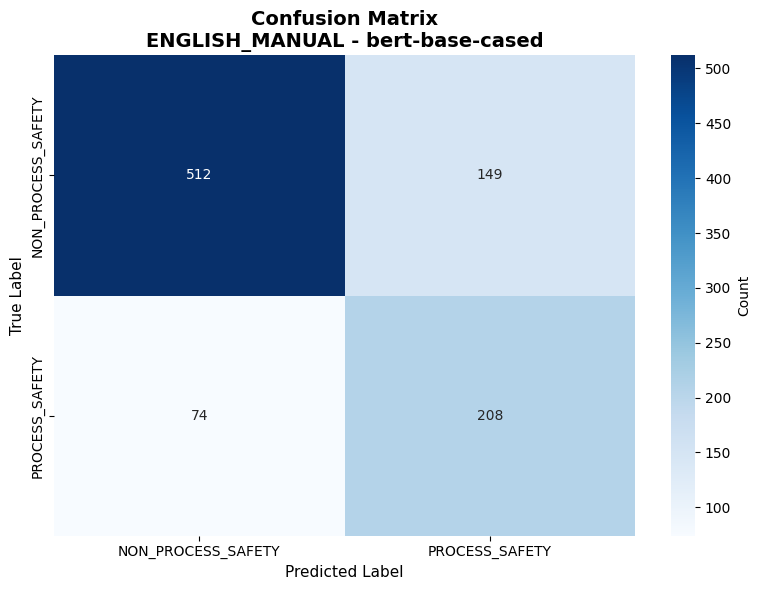


Training SVM: GERMAN_MANUAL | Model: bert-base-cased
Training samples: 11960
Test samples: 2991

Training LinearSVC (max 300s)...
Training completed in 3.20s

Accuracy: 0.7389
F1 Score (weighted): 0.7833
F1 Score (macro): 0.5996

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9480    0.7473    0.8358      2659
    Process Safety     0.2492    0.6717    0.3635       332

          accuracy                         0.7389      2991
         macro avg     0.5986    0.7095    0.5996      2991
      weighted avg     0.8704    0.7389    0.7833      2991


Confusion matrix saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_2/cm_german_manual_bert_base_cased.png


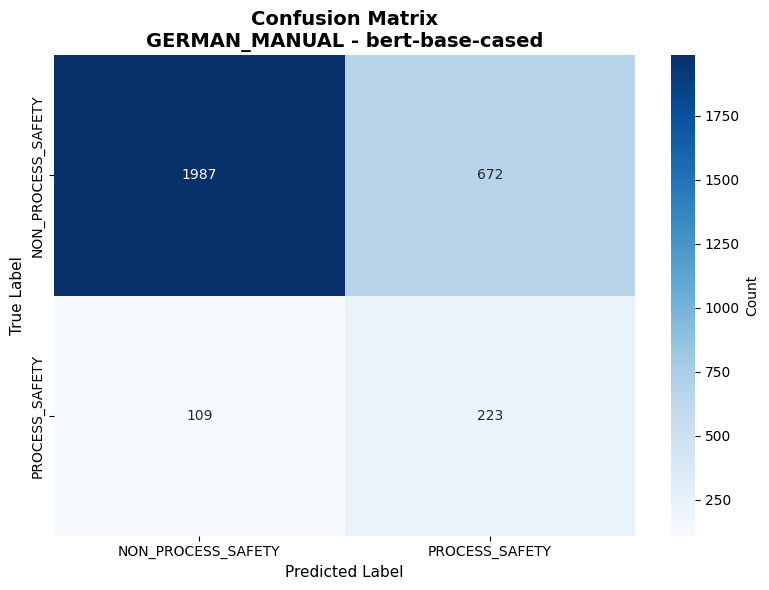


Training SVM: SWEDISH_MANUAL | Model: bert-base-cased
Training samples: 9779
Test samples: 2445

Training LinearSVC (max 300s)...
Training completed in 2.67s

Accuracy: 0.7951
F1 Score (weighted): 0.8426
F1 Score (macro): 0.5819

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9705    0.8057    0.8805      2290
    Process Safety     0.1820    0.6387    0.2833       155

          accuracy                         0.7951      2445
         macro avg     0.5763    0.7222    0.5819      2445
      weighted avg     0.9206    0.7951    0.8426      2445


Confusion matrix saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_2/cm_swedish_manual_bert_base_cased.png


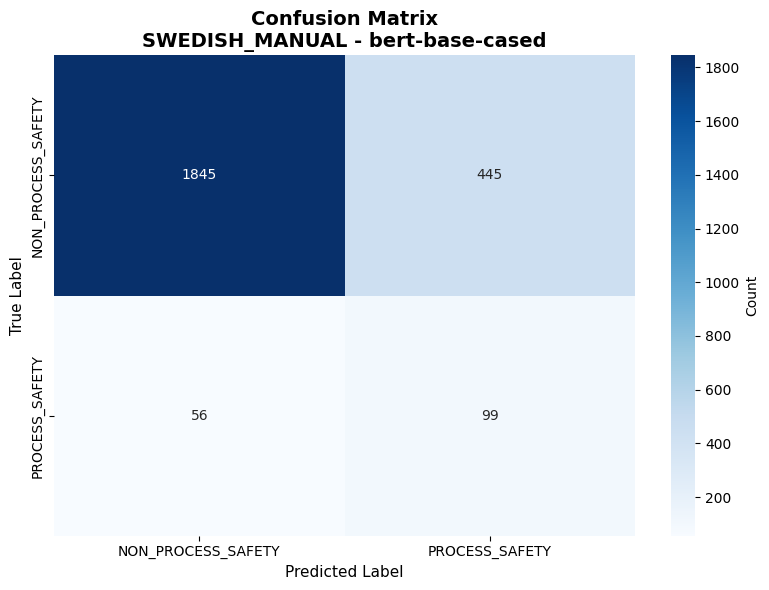


Training SVM: DUTCH_MANUAL | Model: bert-base-cased
Training samples: 1592
Test samples: 398

Training LinearSVC (max 300s)...
Training completed in 0.23s

Accuracy: 0.6658
F1 Score (weighted): 0.6735
F1 Score (macro): 0.6194

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.7860    0.7214    0.7523       280
    Process Safety     0.4468    0.5339    0.4865       118

          accuracy                         0.6658       398
         macro avg     0.6164    0.6277    0.6194       398
      weighted avg     0.6854    0.6658    0.6735       398


Confusion matrix saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_2/cm_dutch_manual_bert_base_cased.png


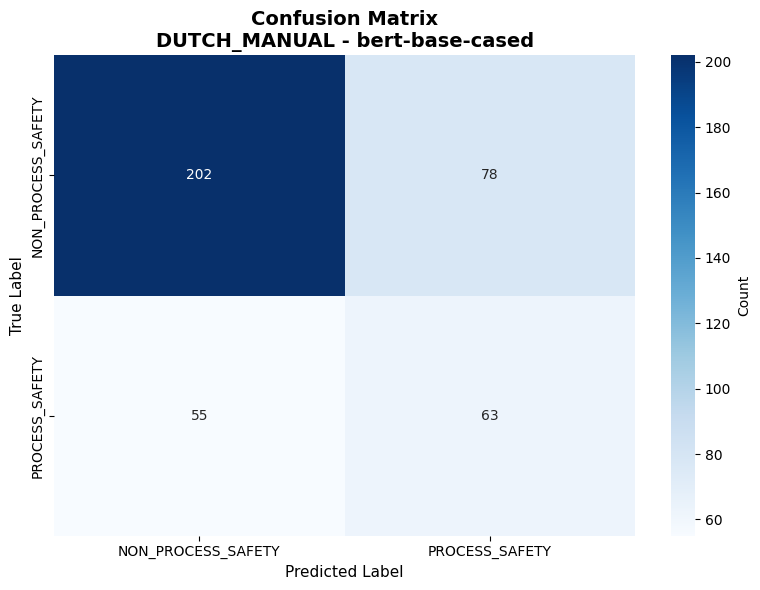


 Processing complete bert-base-cased

################################################################################
MODEL: bert-large-cased (bert-large-cased)
################################################################################

Initializing bert-large-cased...


/Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/.venv/lib/python3.9/site-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Model loaded successfully!

PHASE 1: GENERATING EMBEDDINGS - bert-large-cased

Processing: english_manual | Model: bert-large-cased
Dataset shape: (4713, 36)

Case type distribution:
CASE_TYPE
Safety                              2553
Process Safety                      1409
Environment                          454
Asset and Reputation damage/loss     145
Operational loss                     123
Physical Security                     14
Information Security                  12
Not classified                         3
Name: count, dtype: int64

Generating bert-large-cased embeddings...
Using device: cpu


Generating embeddings: 100%|██████████| 1179/1179 [06:57<00:00,  2.83it/s]



Training set: (3770, 1024)
Test set: (943, 1024)

Class distribution in training set:
binary_label
0    70.11%
1    29.89%
Name: proportion, dtype: object

Embeddings saved!
Location: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_2/bert-large-cased/english_manual_bert-large-cased_embeddings.pkl
Size: 19.96 MB

✗ ERROR processing english_manual with bert-large-cased: name 'csv_files' is not defined


Processing: german_manual | Model: bert-large-cased
Dataset shape: (14951, 36)

Case type distribution:
CASE_TYPE
Safety                              11506
Process Safety                       1661
Environment                          1038
Asset and Reputation damage/loss      518
Information Security                  156
Operational loss                       39
Physical Security                      30
Not classified                          3
Name: count, dtype: int64

Generating bert-large-cased embeddings...
Using device: cpu


...


Training set: (11960, 1024)
Test set: (2991, 1024)

Class distribution in training set:
binary_label
0    88.89%
1    11.11%
Name: proportion, dtype: object

Embeddings saved!
Location: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_2/bert-large-cased/german_manual_bert-large-cased_embeddings.pkl
Size: 61.94 MB

✗ ERROR processing german_manual with bert-large-cased: name 'csv_files' is not defined


Processing: swedish_manual | Model: bert-large-cased
Dataset shape: (12224, 36)

Case type distribution:
CASE_TYPE
Safety                              9974
Process Safety                       773
Environment                          681
Asset and Reputation damage/loss     549
Operational loss                     247
Name: count, dtype: int64

Generating bert-large-cased embeddings...
Using device: cpu


Generating embeddings: 100%|██████████| 3056/3056 [10:19<00:00,  4.94it/s]



Training set: (9779, 1024)
Test set: (2445, 1024)

Class distribution in training set:
binary_label
0    93.68%
1     6.32%
Name: proportion, dtype: object

Embeddings saved!
Location: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_2/bert-large-cased/swedish_manual_bert-large-cased_embeddings.pkl
Size: 49.20 MB

✗ ERROR processing swedish_manual with bert-large-cased: name 'csv_files' is not defined


Processing: dutch_manual | Model: bert-large-cased
Dataset shape: (1990, 36)

Case type distribution:
CASE_TYPE
Safety                              649
Process Safety                      588
Environment                         536
Asset and Reputation damage/loss    110
Operational loss                     45
Physical Security                    45
Information Security                 17
Name: count, dtype: int64

Generating bert-large-cased embeddings...
Using device: cpu


Generating embeddings: 100%|██████████| 498/498 [05:49<00:00,  1.43it/s]



Training set: (1592, 1024)
Test set: (398, 1024)

Class distribution in training set:
binary_label
0    70.48%
1    29.52%
Name: proportion, dtype: object

Embeddings saved!
Location: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_2/bert-large-cased/dutch_manual_bert-large-cased_embeddings.pkl
Size: 8.54 MB

✗ ERROR processing dutch_manual with bert-large-cased: name 'csv_files' is not defined


PHASE 2: TRAINING SVM - bert-large-cased

Training SVM: ENGLISH_MANUAL | Model: bert-large-cased
Training samples: 3770
Test samples: 943

Training LinearSVC (max 300s)...
Training completed in 1.05s

Accuracy: 0.7275
F1 Score (weighted): 0.7338
F1 Score (macro): 0.6915

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.8344    0.7625    0.7968       661
    Process Safety     0.5369    0.6454    0.5862       282

          accuracy                         0.7275       943
         macro avg     0.6857

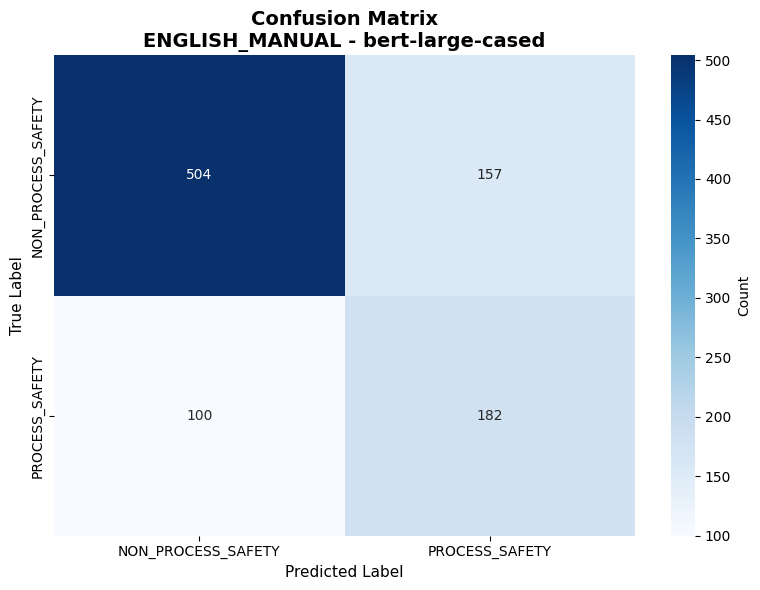


Training SVM: GERMAN_MANUAL | Model: bert-large-cased
Training samples: 11960
Test samples: 2991

Training LinearSVC (max 300s)...
Training completed in 7.44s

Accuracy: 0.7653
F1 Score (weighted): 0.8020
F1 Score (macro): 0.6139

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9438    0.7826    0.8557      2659
    Process Safety     0.2646    0.6265    0.3721       332

          accuracy                         0.7653      2991
         macro avg     0.6042    0.7046    0.6139      2991
      weighted avg     0.8684    0.7653    0.8020      2991


Confusion matrix saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_2/cm_german_manual_bert_large_cased.png


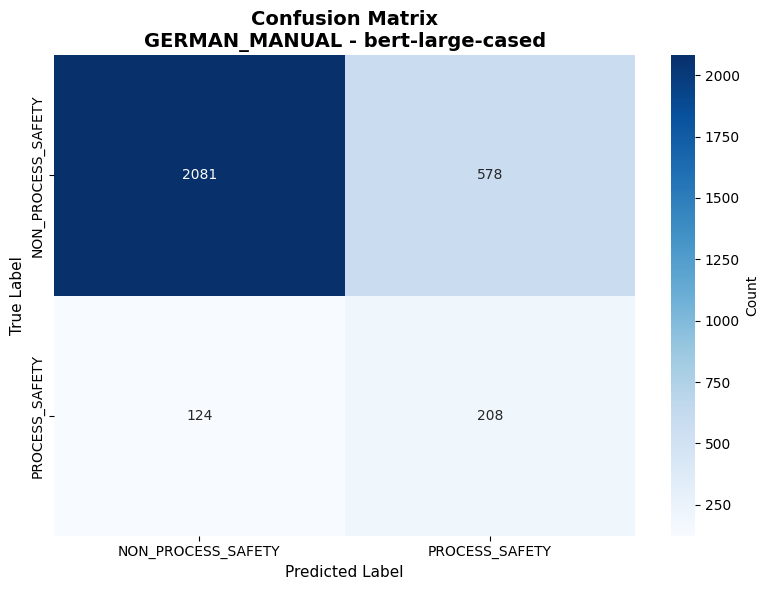


Training SVM: SWEDISH_MANUAL | Model: bert-large-cased
Training samples: 9779
Test samples: 2445

Training LinearSVC (max 300s)...
Training completed in 3.98s

Accuracy: 0.8184
F1 Score (weighted): 0.8568
F1 Score (macro): 0.5854

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9643    0.8371    0.8962      2290
    Process Safety     0.1838    0.5419    0.2745       155

          accuracy                         0.8184      2445
         macro avg     0.5740    0.6895    0.5854      2445
      weighted avg     0.9148    0.8184    0.8568      2445


Confusion matrix saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_2/cm_swedish_manual_bert_large_cased.png


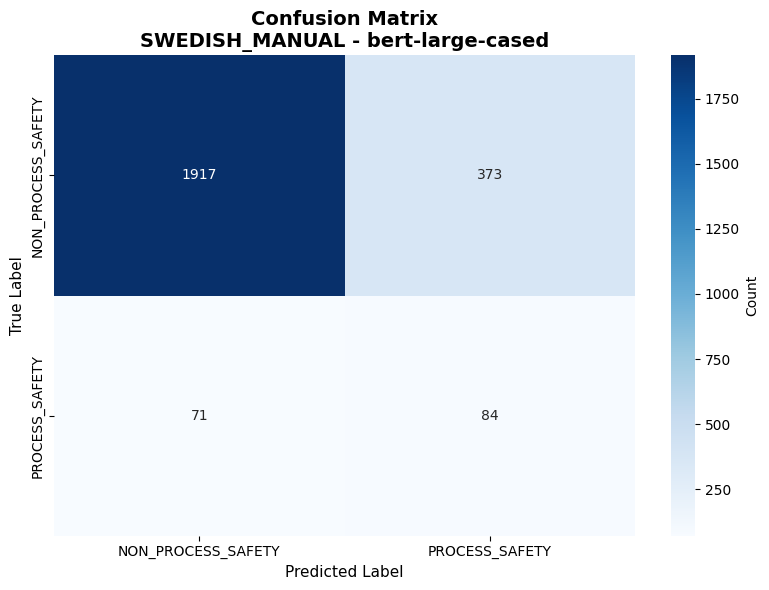


Training SVM: DUTCH_MANUAL | Model: bert-large-cased
Training samples: 1592
Test samples: 398

Training LinearSVC (max 300s)...
Training completed in 0.46s

Accuracy: 0.6231
F1 Score (weighted): 0.6257
F1 Score (macro): 0.5547

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.7372    0.7214    0.7292       280
    Process Safety     0.3710    0.3898    0.3802       118

          accuracy                         0.6231       398
         macro avg     0.5541    0.5556    0.5547       398
      weighted avg     0.6286    0.6231    0.6257       398


Confusion matrix saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_2/cm_dutch_manual_bert_large_cased.png


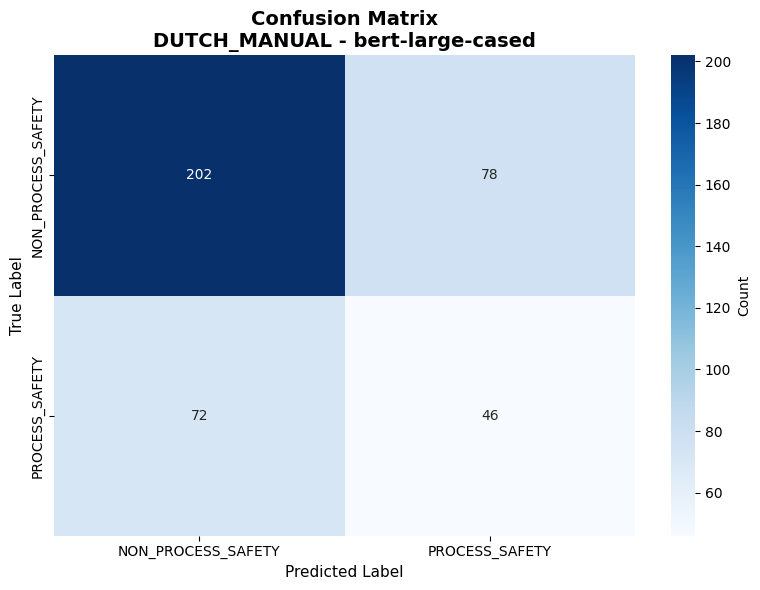


 Processing complete bert-large-cased

################################################################################
MODEL: roberta-base (roberta-base)
################################################################################

Initializing roberta-base...


/Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/.venv/lib/python3.9/site-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded successfully!

PHASE 1: GENERATING EMBEDDINGS - roberta-base

Processing: english_manual | Model: roberta-base
Dataset shape: (4713, 36)

Case type distribution:
CASE_TYPE
Safety                              2553
Process Safety                      1409
Environment                          454
Asset and Reputation damage/loss     145
Operational loss                     123
Physical Security                     14
Information Security                  12
Not classified                         3
Name: count, dtype: int64

Generating roberta-base embeddings...
Using device: cpu


Generating embeddings: 100%|██████████| 1179/1179 [02:08<00:00,  9.14it/s]



Training set: (3770, 768)
Test set: (943, 768)

Class distribution in training set:
binary_label
0    70.11%
1    29.89%
Name: proportion, dtype: object

Embeddings saved!
Location: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_2/roberta-base/english_manual_roberta-base_embeddings.pkl
Size: 15.36 MB

✗ ERROR processing english_manual with roberta-base: name 'csv_files' is not defined


Processing: german_manual | Model: roberta-base
Dataset shape: (14951, 36)

Case type distribution:
CASE_TYPE
Safety                              11506
Process Safety                       1661
Environment                          1038
Asset and Reputation damage/loss      518
Information Security                  156
Operational loss                       39
Physical Security                      30
Not classified                          3
Name: count, dtype: int64

Generating roberta-base embeddings...
Using device: cpu


...


Training set: (11960, 768)
Test set: (2991, 768)

Class distribution in training set:
binary_label
0    88.89%
1    11.11%
Name: proportion, dtype: object

Embeddings saved!
Location: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_2/roberta-base/german_manual_roberta-base_embeddings.pkl
Size: 47.34 MB

✗ ERROR processing german_manual with roberta-base: name 'csv_files' is not defined


Processing: swedish_manual | Model: roberta-base
Dataset shape: (12224, 36)

Case type distribution:
CASE_TYPE
Safety                              9974
Process Safety                       773
Environment                          681
Asset and Reputation damage/loss     549
Operational loss                     247
Name: count, dtype: int64

Generating roberta-base embeddings...
Using device: cpu


Generating embeddings: 100%|██████████| 3056/3056 [03:10<00:00, 16.04it/s]



Training set: (9779, 768)
Test set: (2445, 768)

Class distribution in training set:
binary_label
0    93.68%
1     6.32%
Name: proportion, dtype: object

Embeddings saved!
Location: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_2/roberta-base/swedish_manual_roberta-base_embeddings.pkl
Size: 37.26 MB

✗ ERROR processing swedish_manual with roberta-base: name 'csv_files' is not defined


Processing: dutch_manual | Model: roberta-base
Dataset shape: (1990, 36)

Case type distribution:
CASE_TYPE
Safety                              649
Process Safety                      588
Environment                         536
Asset and Reputation damage/loss    110
Operational loss                     45
Physical Security                    45
Information Security                 17
Name: count, dtype: int64

Generating roberta-base embeddings...
Using device: cpu


Generating embeddings: 100%|██████████| 498/498 [01:47<00:00,  4.65it/s]



Training set: (1592, 768)
Test set: (398, 768)

Class distribution in training set:
binary_label
0    70.48%
1    29.52%
Name: proportion, dtype: object

Embeddings saved!
Location: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_2/roberta-base/dutch_manual_roberta-base_embeddings.pkl
Size: 6.60 MB

✗ ERROR processing dutch_manual with roberta-base: name 'csv_files' is not defined


PHASE 2: TRAINING SVM - roberta-base

Training SVM: ENGLISH_MANUAL | Model: roberta-base
Training samples: 3770
Test samples: 943

Training LinearSVC (max 300s)...
Training completed in 0.31s

Accuracy: 0.7953
F1 Score (weighted): 0.8006
F1 Score (macro): 0.7698

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.8926    0.8048    0.8465       661
    Process Safety     0.6282    0.7730    0.6932       282

          accuracy                         0.7953       943
         macro avg     0.7604    0.7889    0.7698  

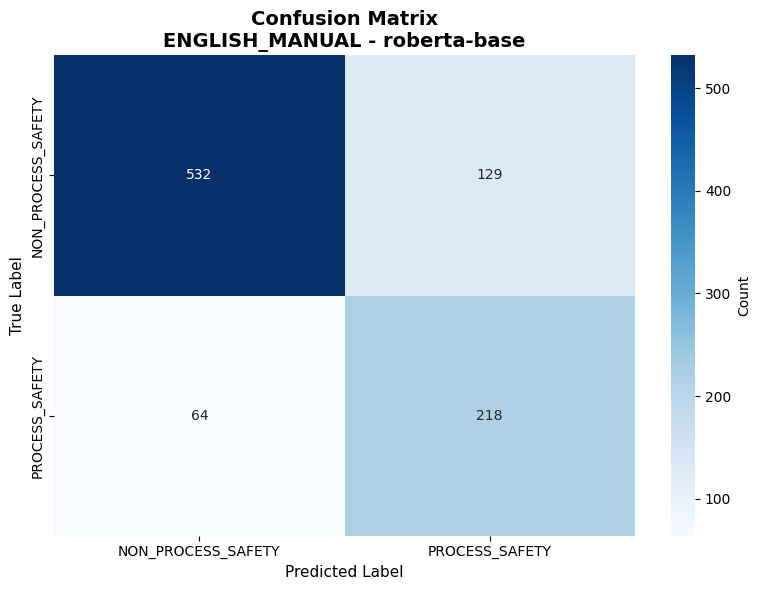


Training SVM: GERMAN_MANUAL | Model: roberta-base
Training samples: 11960
Test samples: 2991

Training LinearSVC (max 300s)...
Training completed in 1.38s

Accuracy: 0.7636
F1 Score (weighted): 0.8024
F1 Score (macro): 0.6251

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9540    0.7713    0.8530      2659
    Process Safety     0.2771    0.7018    0.3973       332

          accuracy                         0.7636      2991
         macro avg     0.6155    0.7366    0.6251      2991
      weighted avg     0.8788    0.7636    0.8024      2991


Confusion matrix saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_2/cm_german_manual_roberta_base.png


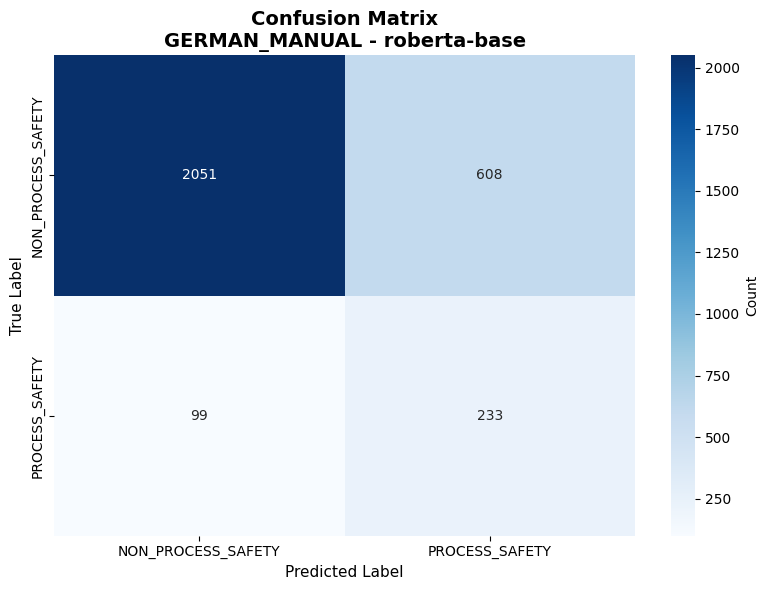


Training SVM: SWEDISH_MANUAL | Model: roberta-base
Training samples: 9779
Test samples: 2445

Training LinearSVC (max 300s)...
Training completed in 1.07s

Accuracy: 0.7542
F1 Score (weighted): 0.8149
F1 Score (macro): 0.5531

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9705    0.7607    0.8529      2290
    Process Safety     0.1569    0.6581    0.2534       155

          accuracy                         0.7542      2445
         macro avg     0.5637    0.7094    0.5531      2445
      weighted avg     0.9189    0.7542    0.8149      2445


Confusion matrix saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_2/cm_swedish_manual_roberta_base.png


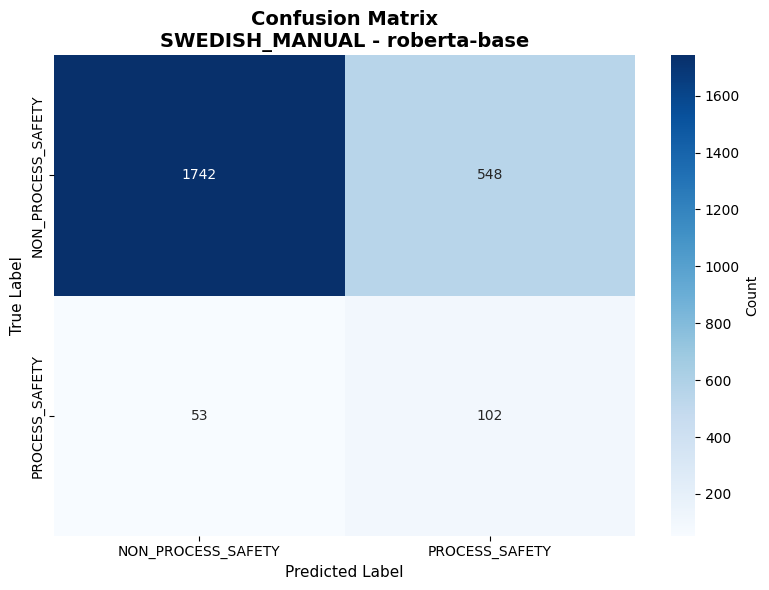


Training SVM: DUTCH_MANUAL | Model: roberta-base
Training samples: 1592
Test samples: 398

Training LinearSVC (max 300s)...
Training completed in 0.08s

Accuracy: 0.6910
F1 Score (weighted): 0.7022
F1 Score (macro): 0.6617

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.8340    0.7000    0.7612       280
    Process Safety     0.4847    0.6695    0.5623       118

          accuracy                         0.6910       398
         macro avg     0.6594    0.6847    0.6617       398
      weighted avg     0.7305    0.6910    0.7022       398


Confusion matrix saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_2/cm_dutch_manual_roberta_base.png


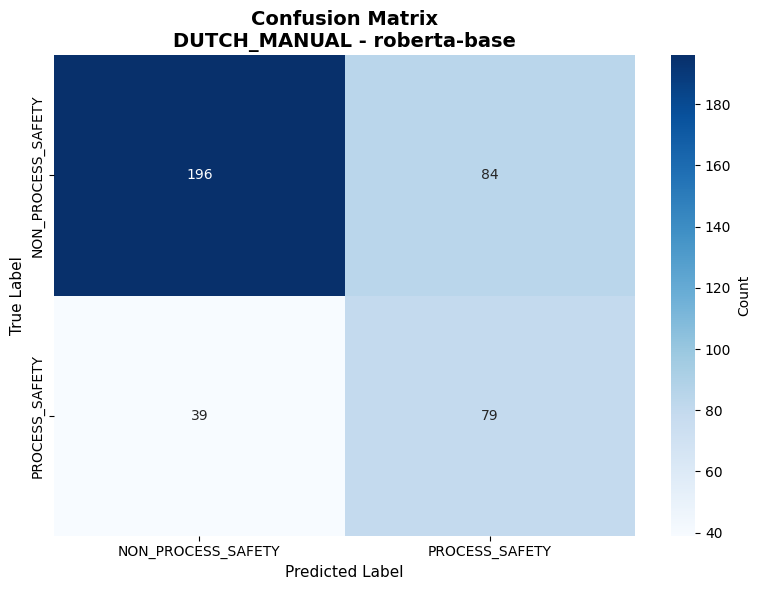


 Processing complete roberta-base

################################################################################
MODEL: roberta-large (roberta-large)
################################################################################

Initializing roberta-large...


/Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/.venv/lib/python3.9/site-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded successfully!

PHASE 1: GENERATING EMBEDDINGS - roberta-large

Processing: english_manual | Model: roberta-large
Dataset shape: (4713, 36)

Case type distribution:
CASE_TYPE
Safety                              2553
Process Safety                      1409
Environment                          454
Asset and Reputation damage/loss     145
Operational loss                     123
Physical Security                     14
Information Security                  12
Not classified                         3
Name: count, dtype: int64

Generating roberta-large embeddings...
Using device: cpu


Generating embeddings: 100%|██████████| 1179/1179 [06:47<00:00,  2.89it/s]



Training set: (3770, 1024)
Test set: (943, 1024)

Class distribution in training set:
binary_label
0    70.11%
1    29.89%
Name: proportion, dtype: object

Embeddings saved!
Location: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_2/roberta-large/english_manual_roberta-large_embeddings.pkl
Size: 19.96 MB

✗ ERROR processing english_manual with roberta-large: name 'csv_files' is not defined


Processing: german_manual | Model: roberta-large
Dataset shape: (14951, 36)

Case type distribution:
CASE_TYPE
Safety                              11506
Process Safety                       1661
Environment                          1038
Asset and Reputation damage/loss      518
Information Security                  156
Operational loss                       39
Physical Security                      30
Not classified                          3
Name: count, dtype: int64

Generating roberta-large embeddings...
Using device: cpu


Generating embeddings: 100%|██████████| 3738/3738 [24:52<00:00,  2.50it/s] 



Training set: (11960, 1024)
Test set: (2991, 1024)

Class distribution in training set:
binary_label
0    88.89%
1    11.11%
Name: proportion, dtype: object

Embeddings saved!
Location: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_2/roberta-large/german_manual_roberta-large_embeddings.pkl
Size: 61.94 MB

✗ ERROR processing german_manual with roberta-large: name 'csv_files' is not defined


Processing: swedish_manual | Model: roberta-large
Dataset shape: (12224, 36)

Case type distribution:
CASE_TYPE
Safety                              9974
Process Safety                       773
Environment                          681
Asset and Reputation damage/loss     549
Operational loss                     247
Name: count, dtype: int64

Generating roberta-large embeddings...
Using device: cpu


Generating embeddings:  10%|█         | 317/3056 [01:09<09:59,  4.57it/s]
[E thread_pool.cpp:110] Exception in thread pool task: mutex lock failed: Invalid argument
[E thread_pool.cpp:110] Exception in thread pool task: mutex lock failed: Invalid argument


KeyboardInterrupt: 

In [34]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModel
import torch
from tqdm import tqdm
import pickle
import glob
import gc
import json
import time
from multiprocessing import Process, Queue
import signal

# ============================================================
# Configuration
# ============================================================

# Use PATHS from earlier configuration (already cross-platform)
DATA_DIR = str(PATHS['master_dataset'] / 'By_SL_Country')
EMBEDDINGS_BASE_DIR = str(PATHS['embeddings'])
RESULTS_DIR = str(PATHS['results'])
CHECKPOINT_FILE = str(PATHS['results'] / "checkpoint.json")

# Create directories
os.makedirs(EMBEDDINGS_BASE_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(os.path.dirname(CHECKPOINT_FILE), exist_ok=True)

# Model configurations
MODELS = {
    'bert-base-cased': 'bert-base-cased',
    'bert-large-cased': 'bert-large-cased',
    'roberta-base': 'roberta-base',
    'roberta-large': 'roberta-large',
    'distilbert-base-cased': 'distilbert-base-cased',
    'xlnet-base-cased': 'xlnet-base-cased'
}

# Datasets to skip
SKIP_DATASETS = [
    'master_df_Hungary_manual.json',
    'master_df_International_manual.json',
    'master_df_Russia_manual.json',
    'master_df_UAE_manual.json',
    'master_df_Poland_manual.json',
    'master_df_Unknown_manual.json',
]

# Timeout and memory management settings
MAX_PROCESSING_TIME = 3600 * 3  # 3 hours in seconds
BATCH_SIZE = 4  # Reduce to prevent memory issues
SVM_TIMEOUT = 300  # 5 minutes timeout for SVM training
MAX_SAMPLES_SVM = 60000  # Limit samples for large datasets 

# ============================================================
# Checkpoint Functions
# ============================================================

def save_checkpoint(processed_items):
    """Save checkpoint with processed model-dataset combinations"""
    with open(CHECKPOINT_FILE, 'w') as f:
        json.dump({'processed': list(processed_items)}, f)

def load_checkpoint():
    """Load checkpoint"""
    if os.path.exists(CHECKPOINT_FILE):
        with open(CHECKPOINT_FILE, 'r') as f:
            return set(tuple(item) for item in json.load(f)['processed'])
    return set()

# ============================================================
# Functions
# ============================================================

def get_bert_embeddings(texts, tokenizer, model, max_length=512, batch_size=4):
    """Generate BERT embeddings for a list of texts with memory management"""
    embeddings = []
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model = model.to(device)
    
    print(f"Using device: {device}")
    
    for i in tqdm(range(0, len(texts), batch_size), desc="Generating embeddings"):
        batch_texts = texts[i:i + batch_size]
        
        inputs = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        ).to(device)
        
        with torch.no_grad():
            outputs = model(**inputs)
            batch_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            embeddings.extend(batch_embeddings)
        
        # Clear GPU memory after each batch
        if device == 'cuda':
            torch.cuda.empty_cache()
        
        # Clear CPU memory periodically
        if i % 50 == 0 and i > 0:
            gc.collect()
    
    return np.array(embeddings)


def process_dataset(json_file, model_name, model_key, tokenizer, model, dataset_name=None):
    """Process a single CSV dataset and save embeddings"""
    # dataset_name comes from DATASET_FILES dict key (e.g. 'english_lingua')
    if dataset_name is None:
        dataset_name = os.path.basename(json_file).replace('master_df_', '').replace('.json', '').lower()
    
    print(f"\n{'='*80}")
    print(f"Processing: {dataset_name} | Model: {model_key}")
    print(f"{'='*80}")
    
    # Load dataset from Iteration 0 pre-processed JSON (no re-preprocessing needed)
    df = pd.read_json(json_file)
    if 'LANGUAGE' in df.columns:
        df['LANGUAGE_CODE'] = df['LANGUAGE'].map(LANGUAGE_CODE_MAP).fillna('UN')
    print(f"Dataset shape: {df.shape}")
    print(f"\nCase type distribution:")
    print(df['CASE_TYPE'].value_counts())
    
    # Create binary labels
    df['binary_label'] = df['CASE_TYPE'].apply(lambda x: 1 if x == 'Process Safety' else 0)
    
    # Combine title and description
    df['text_features'] = df['TITLE'] + '. ' + df['CASE_DESCRIPTION']
    
    # Generate embeddings
    print(f"\nGenerating {model_name} embeddings...")
    X = get_bert_embeddings(
        df['text_features'].tolist(), 
        tokenizer, 
        model, 
        batch_size=BATCH_SIZE
    )
    y = df['binary_label']
    
    # Split dataset
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    print(f"\nTraining set: {X_train.shape}")
    print(f"Test set: {X_test.shape}")
    
    # Subsample if training set is too large
    if X_train.shape[0] > MAX_SAMPLES_SVM:
        print(f"\nWARNING: Training set too large ({X_train.shape[0]} samples)")
        print(f"Subsampling to {MAX_SAMPLES_SVM} samples for SVM efficiency...")
        from sklearn.utils import resample
        X_train_subset, y_train_subset = resample(
            X_train, y_train, 
            n_samples=MAX_SAMPLES_SVM, 
            stratify=y_train, 
            random_state=42
        )
        print(f"Subsampled training set: {X_train_subset.shape}")
    else:
        X_train_subset = X_train
        y_train_subset = y_train
    
    print(f"\nClass distribution in training set:")
    print(pd.Series(y_train).value_counts(normalize=True).map(lambda x: f"{x:.2%}"))
    
    # Create model-specific directory
    model_short_name = model_name.replace('/', '_')
    model_dir = os.path.join(EMBEDDINGS_BASE_DIR, model_short_name)
    os.makedirs(model_dir, exist_ok=True)
    
    # Save embeddings (save both full and subset)
    embeddings_data = {
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'X_train_subset': X_train_subset,
        'y_train_subset': y_train_subset,
        'feature_names': df['text_features'].tolist(),
        'metadata': {
            'model': model_name,
            'model_key': model_key,
            'dataset': dataset_name,
            'embedding_dim': X_train.shape[1],
            'train_size': X_train.shape[0],
            'train_subset_size': X_train_subset.shape[0],
            'test_size': X_test.shape[0],
            'random_state': 42,
            'subsampled': X_train.shape[0] > MAX_SAMPLES_SVM
        }
    }
    
    pkl_file = os.path.join(model_dir, f'{dataset_name}_{model_short_name}_embeddings.pkl')
    
    with open(pkl_file, 'wb') as f:
        pickle.dump(embeddings_data, f)
    
    print(f"\n{'='*60}")
    print(f"Embeddings saved!")
    print(f"Location: {pkl_file}")
    print(f"Size: {os.path.getsize(pkl_file) / 1024**2:.2f} MB")
    print(f"{'='*60}\n")
    
    # Clear memory after processing
    del df, X, y, X_train, X_test, y_train, y_test, X_train_subset, y_train_subset, embeddings_data
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    
    return pkl_file


def train_svm_and_evaluate(embeddings_file):
    """Load embeddings, train SVM, and generate confusion matrix"""
    
    # Load embeddings
    with open(embeddings_file, 'rb') as f:
        embeddings_data = pickle.load(f)
    
    # Use subset for training if available
    X_train = embeddings_data.get('X_train_subset', embeddings_data['X_train'])
    y_train = embeddings_data.get('y_train_subset', embeddings_data['y_train'])
    X_test = embeddings_data['X_test']
    y_test = embeddings_data['y_test']
    metadata = embeddings_data['metadata']
    
    dataset_name = metadata['dataset']
    model_name = metadata['model']
    model_key = metadata.get('model_key', model_name)
    
    print(f"\n{'='*80}")
    print(f"Training SVM: {dataset_name.upper()} | Model: {model_key}")
    print(f"{'='*80}")
    print(f"Training samples: {X_train.shape[0]}")
    print(f"Test samples: {X_test.shape[0]}")
    
    # Use faster LinearSVC instead of SVC with timeout protection
    try:
        from sklearn.svm import LinearSVC
        from sklearn.metrics import precision_recall_fscore_support
        
        print(f"\nTraining LinearSVC (max {SVM_TIMEOUT}s)...")
        start_time = time.time()
        
        svm_model = LinearSVC(class_weight='balanced', max_iter=1000, dual=False, random_state=42)
        svm_model.fit(X_train, y_train)
        
        training_time = time.time() - start_time
        print(f"Training completed in {training_time:.2f}s")
        
        # Make predictions
        y_pred = svm_model.predict(X_test)
        
        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        f1_weighted = f1_score(y_test, y_pred, average='weighted')
        f1_macro = f1_score(y_test, y_pred, average='macro')
        
        # Get per-class metrics
        precision, recall, f1, support = precision_recall_fscore_support(
            y_test, y_pred, average=None, labels=[0, 1]
        )
        
        print(f"\nAccuracy: {accuracy:.4f}")
        print(f"F1 Score (weighted): {f1_weighted:.4f}")
        print(f"F1 Score (macro): {f1_macro:.4f}")
        
        # Print classification report
        print("\nClassification Report:")
        print(classification_report(
            y_test, y_pred,
            target_names=['Non-Process Safety', 'Process Safety'],
            digits=4
        ))
        
        # Create confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        
        # Create visualization
        plt.figure(figsize=(8, 6))
        sns.heatmap(
            cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NON_PROCESS_SAFETY', 'PROCESS_SAFETY'],
            yticklabels=['NON_PROCESS_SAFETY', 'PROCESS_SAFETY'],
            cbar_kws={'label': 'Count'}
        )
        
        # Create safe filename
        model_short = model_name.replace('/', '_').replace('-', '_')
        plt.title(f'Confusion Matrix\n{dataset_name.upper()} - {model_key}', 
                  fontsize=14, fontweight='bold')
        plt.ylabel('True Label', fontsize=11)
        plt.xlabel('Predicted Label', fontsize=11)
        plt.tight_layout()
        
        # Save plot
        plot_filename = f'cm_{dataset_name}_{model_short}.png'
        plot_path = os.path.join(RESULTS_DIR, plot_filename)
        plt.savefig(plot_path, dpi=300, bbox_inches='tight')
        print(f"\nConfusion matrix saved to: {plot_path}")
        plt.show()
        
        # Clear memory
        plt.close()
        del embeddings_data, X_train, X_test, y_train, y_test
        gc.collect()
        
        return {
            'dataset': dataset_name,
            'model': model_key,
            'model_full': model_name,
            'accuracy': accuracy,
            'f1_weighted': f1_weighted,
            'f1_macro': f1_macro,
            # Non-Process Safety (class 0) metrics
            'precision_non_ps': precision[0],
            'recall_non_ps': recall[0],
            'f1_non_ps': f1[0],
            'support_non_ps': support[0],
            # Process Safety (class 1) metrics
            'precision_ps': precision[1],
            'recall_ps': recall[1],
            'f1_ps': f1[1],
            'support_ps': support[1],
            'training_time': training_time,
            'confusion_matrix': cm.tolist(),
            'pkl_file': os.path.basename(embeddings_file),
            'subsampled': metadata.get('subsampled', False)
        }
        
    except Exception as e:
        print(f"\nERROR training SVM: {str(e)}")
        del embeddings_data, X_train, X_test, y_train, y_test
        gc.collect()
        raise


# ============================================================
# Main Execution
# ============================================================

print("\n" + "#"*80)
print("MULTI-MODEL EMBEDDING AND SVM TRAINING PIPELINE")
print("#"*80)

# Use JSON dataset files defined in Cell 2 (from Iteration 0 outputs)
json_files = list(DATASET_FILES.items())  # [(name, path), ...]

print(f"\nDatasets to process: {len(json_files)}")
for name, path in json_files:
    print(f"  {name}: {os.path.basename(path)}")
print(f"\nFound {len(MODELS)} models to use")
print(f"Total combinations: {len(json_files) * len(MODELS)}")

# Load checkpoint
processed_items = load_checkpoint()
print(f"Already processed: {len(processed_items)} combinations")

# Track all results
all_results = []
start_time = time.time()

# Process each model
for model_key, model_name in MODELS.items():
    print(f"\n{'#'*80}")
    print(f"MODEL: {model_key} ({model_name})")
    print(f"{'#'*80}")
    
    try:
        # Initialize model
        print(f"\nInitializing {model_key}...")
        tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
        model = AutoModel.from_pretrained(model_name, trust_remote_code=True)
        print(f"Model loaded successfully!")
        
        # Phase 1: Generate embeddings for all datasets
        print(f"\n{'='*80}")
        print(f"PHASE 1: GENERATING EMBEDDINGS - {model_key}")
        print(f"{'='*80}")
        
        pkl_files = []
        
        for dataset_name, json_file in json_files:
            # dataset_name is already the key from DATASET_FILES dict
            item_key = (model_key, dataset_name)
            
            # Check if already processed
            if item_key in processed_items:
                print(f"\nSkipping already processed: {dataset_name} with {model_key}")
                model_short_name = model_name.replace('/', '_')
                pkl_file = os.path.join(EMBEDDINGS_BASE_DIR, model_short_name, 
                                       f'{dataset_name}_{model_short_name}_embeddings.pkl')
                if os.path.exists(pkl_file):
                    pkl_files.append(pkl_file)
                continue
            
            # Check timeout
            elapsed_time = time.time() - start_time
            if elapsed_time > MAX_PROCESSING_TIME:
                print(f"\nReached time limit ({MAX_PROCESSING_TIME/60:.1f} minutes).")
                print(f"Resume by running this cell again - checkpoint saved.")
                break
            
            try:
                pkl_file = process_dataset(json_file, model_name, model_key, tokenizer, model, dataset_name=dataset_name)
                pkl_files.append(pkl_file)
                
                # Save checkpoint
                processed_items.add(item_key)
                save_checkpoint(processed_items)
                
                print(f"Checkpoint saved. Progress: {len(processed_items)}/{len(json_files) * len(MODELS)}")
                
            except Exception as e:
                print(f"✗ ERROR processing {dataset_name} with {model_key}: {str(e)}\n")
                continue
        
        # Phase 2: Train SVM for this model's embeddings
        print(f"\n{'='*80}")
        print(f"PHASE 2: TRAINING SVM - {model_key}")
        print(f"{'='*80}")
        
        for pkl_file in pkl_files:
            try:
                result = train_svm_and_evaluate(pkl_file)
                all_results.append(result)
                
            except Exception as e:
                dataset_name = os.path.basename(pkl_file).split('_')[0]
                print(f"ERROR training SVM for {dataset_name} with {model_key}: {str(e)}\n")
                all_results.append({
                    'dataset': dataset_name,
                    'model': model_key,
                    'model_full': model_name,
                    'accuracy': None,
                    'f1_weighted': None,
                    'f1_macro': None,
                    'status': f'failed: {str(e)}'
                })
                continue
        
        # Clear model from memory
        del tokenizer, model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        
        print(f"\n Processing complete {model_key}")
        
    except Exception as e:
        print(f"\nERROR loading model {model_key}: {str(e)}")
        print(f"Skipping this model and continuing with next...\n")
        continue

# ============================================================
# Final Summary
# ============================================================

print("\n" + "#"*80)
print("FINAL SUMMARY")
print("#"*80 + "\n")

if all_results:
    results_df = pd.DataFrame(all_results)
    
    # Display DETAILED results table
    print("="*100)
    print("DETAILED RESULTS TABLE")
    print("="*100)
    
    # Format the detailed table
    detailed_cols = [
        'dataset', 'model', 'accuracy', 'f1_weighted', 'f1_macro',
        'precision_non_ps', 'recall_non_ps', 'f1_non_ps', 'support_non_ps',
        'precision_ps', 'recall_ps', 'f1_ps', 'support_ps'
    ]
    
    # Check which columns exist
    display_cols = [col for col in detailed_cols if col in results_df.columns]
    
    if 'training_time' in results_df.columns:
        display_cols.append('training_time')
    if 'subsampled' in results_df.columns:
        display_cols.append('subsampled')
    
    # Create a formatted display DataFrame
    display_df = results_df[display_cols].copy()
    
    # Round numeric columns for better display
    numeric_cols = ['accuracy', 'f1_weighted', 'f1_macro', 
                    'precision_non_ps', 'recall_non_ps', 'f1_non_ps',
                    'precision_ps', 'recall_ps', 'f1_ps']
    
    for col in numeric_cols:
        if col in display_df.columns:
            display_df[col] = display_df[col].round(4)
    
    if 'training_time' in display_df.columns:
        display_df['training_time'] = display_df['training_time'].round(2)
    
    print(display_df.to_string(index=False))
    
    # Save detailed results to CSV
    summary_file = os.path.join(RESULTS_DIR, 'all_models_svm_detailed_results.csv')
    results_df.to_csv(summary_file, index=False)
    print(f"\nDetailed results saved to: {summary_file}")
    
    # Create a formatted classification report style table
    print(f"\n{'='*100}")
    print("CLASSIFICATION METRICS BY MODEL-DATASET COMBINATION")
    print(f"{'='*100}\n")
    
    for idx, row in results_df.iterrows():
        if pd.notna(row.get('accuracy')):
            print(f"Dataset: {row['dataset'].upper():20s} | Model: {row['model']}")
            print("-" * 80)
            print(f"{'':25s} precision    recall  f1-score   support")
            print()
            print(f"{'Non-Process Safety':25s}   {row['precision_non_ps']:.2f}      {row['recall_non_ps']:.2f}      {row['f1_non_ps']:.2f}    {int(row['support_non_ps']):7d}")
            print(f"{'Process Safety':25s}   {row['precision_ps']:.2f}      {row['recall_ps']:.2f}      {row['f1_ps']:.2f}    {int(row['support_ps']):7d}")
            print()
            total_support = int(row['support_non_ps'] + row['support_ps'])
            print(f"{'accuracy':25s}                           {row['accuracy']:.2f}    {total_support:7d}")
            print(f"{'macro avg':25s}   {(row['precision_non_ps'] + row['precision_ps'])/2:.2f}      {(row['recall_non_ps'] + row['recall_ps'])/2:.2f}      {row['f1_macro']:.2f}    {total_support:7d}")
            print(f"{'weighted avg':25s}   {((row['precision_non_ps']*row['support_non_ps'] + row['precision_ps']*row['support_ps'])/total_support):.2f}      {((row['recall_non_ps']*row['support_non_ps'] + row['recall_ps']*row['support_ps'])/total_support):.2f}      {row['f1_weighted']:.2f}    {total_support:7d}")
            print()
    
    # Statistics
    print(f"\n{'='*80}")
    print("AGGREGATE STATISTICS")
    print(f"{'='*80}")
    print(f"Total combinations processed: {len(results_df)}")
    print(f"Successful: {results_df['accuracy'].notna().sum()}")
    print(f"Failed: {results_df['accuracy'].isna().sum()}")
    
    if results_df['accuracy'].notna().any():
        print(f"\nOverall Accuracy Statistics:")
        print(f"  Min: {results_df['accuracy'].min():.4f}")
        print(f"  Max: {results_df['accuracy'].max():.4f}")
        print(f"  Mean: {results_df['accuracy'].mean():.4f}")
        print(f"  Std: {results_df['accuracy'].std():.4f}")
        
        print(f"\nF1 Score (Weighted) Statistics:")
        print(f"  Min: {results_df['f1_weighted'].min():.4f}")
        print(f"  Max: {results_df['f1_weighted'].max():.4f}")
        print(f"  Mean: {results_df['f1_weighted'].mean():.4f}")
        print(f"  Std: {results_df['f1_weighted'].std():.4f}")
        
        print(f"\nProcess Safety Class Metrics (Average):")
        print(f"  Precision: {results_df['precision_ps'].mean():.4f}")
        print(f"  Recall: {results_df['recall_ps'].mean():.4f}")
        print(f"  F1-Score: {results_df['f1_ps'].mean():.4f}")
        
        print(f"\nNon-Process Safety Class Metrics (Average):")
        print(f"  Precision: {results_df['precision_non_ps'].mean():.4f}")
        print(f"  Recall: {results_df['recall_non_ps'].mean():.4f}")
        print(f"  F1-Score: {results_df['f1_non_ps'].mean():.4f}")
        
        if 'training_time' in results_df.columns:
            print(f"\nTraining Time Statistics:")
            print(f"  Min: {results_df['training_time'].min():.2f}s")
            print(f"  Max: {results_df['training_time'].max():.2f}s")
            print(f"  Mean: {results_df['training_time'].mean():.2f}s")
        
        # Best performing combination
        best_idx = results_df['accuracy'].idxmax()
        print(f"\n{'='*80}")
        print("BEST PERFORMING MODEL (by Accuracy)")
        print(f"{'='*80}")
        print(f"Dataset: {results_df.loc[best_idx, 'dataset']}")
        print(f"Model: {results_df.loc[best_idx, 'model']}")
        print(f"Accuracy: {results_df.loc[best_idx, 'accuracy']:.4f}")
        print(f"F1 Score (weighted): {results_df.loc[best_idx, 'f1_weighted']:.4f}")
        print(f"F1 Score (macro): {results_df.loc[best_idx, 'f1_macro']:.4f}")
        
        # Best by F1 for Process Safety class
        best_ps_idx = results_df['f1_ps'].idxmax()
        print(f"\n{'='*80}")
        print("BEST FOR PROCESS SAFETY CLASS (by F1-Score)")
        print(f"{'='*80}")
        print(f"Dataset: {results_df.loc[best_ps_idx, 'dataset']}")
        print(f"Model: {results_df.loc[best_ps_idx, 'model']}")
        print(f"Process Safety F1: {results_df.loc[best_ps_idx, 'f1_ps']:.4f}")
        print(f"Process Safety Precision: {results_df.loc[best_ps_idx, 'precision_ps']:.4f}")
        print(f"Process Safety Recall: {results_df.loc[best_ps_idx, 'recall_ps']:.4f}")
        
        # Results by model
        print(f"\n{'='*80}")
        print("AVERAGE PERFORMANCE BY MODEL")
        print(f"{'='*80}")
        model_stats = results_df.groupby('model')[['accuracy', 'f1_weighted', 'f1_macro', 
                                                     'precision_ps', 'recall_ps', 'f1_ps']].agg(['mean', 'std'])
        print(model_stats.to_string())
        
        # Results by dataset
        print(f"\n{'='*80}")
        print("AVERAGE PERFORMANCE BY DATASET")
        print(f"{'='*80}")
        dataset_stats = results_df.groupby('dataset')[['accuracy', 'f1_weighted', 'f1_macro',
                                                         'precision_ps', 'recall_ps', 'f1_ps']].agg(['mean', 'std'])
        print(dataset_stats.to_string())

else:
    print("No results to display.")

# Clear checkpoint if all completed
total_combinations = len(json_files) * len(MODELS)
if len(processed_items) == total_combinations:
    print(f"\n{'='*80}")
    print("ALL COMBINATIONS PROCESSED!")
    print(f"{'='*80}")
    if os.path.exists(CHECKPOINT_FILE):
        os.remove(CHECKPOINT_FILE)
        print("Checkpoint file cleared.")

print(f"\nTotal execution time: {(time.time() - start_time)/60:.2f} minutes")
print("\n" + "#"*80)
print("PIPELINE COMPLETE")
print("#"*80)

# =============================================================================
# Save iteration_2_summary.json (consistent with Iteration 0 format)
# =============================================================================
if all_results:
    import json as _json
    import pandas as _pd

    _results_df = _pd.DataFrame(all_results)
    _RQ1_TARGET = 0.85
    _best_idx = _results_df['macro_f1'].idxmax() if 'macro_f1' in _results_df.columns else 0

    _summary = {
        'iteration': 2,
        'model': '6 BERT-family models (bert-base-cased, bert-large-cased, roberta-base, '
                 'roberta-large, distilbert-base-cased, xlnet-base-cased) + LinearSVC',
        'best_dataset': str(_results_df.loc[_best_idx, 'dataset']) if len(_results_df) > 0 else '',
        'best_model':   str(_results_df.loc[_best_idx, 'model']) if len(_results_df) > 0 else '',
        'datasets': {},
        'gap_analysis': {}
    }

    for _, row in _results_df.iterrows():
        key = f"{row['dataset']}__{row.get('model', 'unknown')}"
        _summary['datasets'][key] = {
            'results': {
                'accuracy':     round(float(row.get('accuracy', 0)), 4),
                'macro_f1':     round(float(row.get('macro_f1', 0)), 4),
                'precision_ps': round(float(row.get('precision_ps', 0)), 4),
                'recall_ps':    round(float(row.get('recall_ps', 0)), 4),
            }
        }
        _summary['gap_analysis'][key] = {
            'current_macro_f1': round(float(row.get('macro_f1', 0)), 4),
            'rq1_target': _RQ1_TARGET,
            'gap': round(float(_RQ1_TARGET - row.get('macro_f1', 0)), 4)
        }

    _out_path = os.path.join(RESULTS_DIR, 'iteration_2_summary.json')
    with open(_out_path, 'w', encoding='utf-8') as _f:
        _json.dump(_summary, _f, indent=2, ensure_ascii=False)
    print(f"[OK] Saved: {_out_path}")